# **Course 4 - Unsupervised Machine Learning**
**News Article Analysis project**

## **Introduction**

### **Project overview**

This analysis uses the **20 Newsgroups** dataset, which contains discussion posts from multiple topics such as technology, science, politics, sports, and religion. Because the documents are unstructured and high-dimensional, the project applies clustering and dimensionality reduction techniques to identify hidden patterns, group related documents, and create simpler representations that are easier to analyze and visualize.

The main goal of this project is to explore whether unsupervised learning can automatically identify important discussion themes, emerging topics, and relationships between documents. In real-world settings, organizations often manage massive volumes of news articles, online discussions, customer feedback, technical reports, and social media content that cannot be reviewed manually at scale.

By organizing similar documents into meaningful groups, unsupervised learning may help analysts and decision makers improve document search, topic discovery, content summarization, trend analysis, and information exploration.





### **Objective**
The overall objective of this project is to evaluate how different unsupervised learning methods can organize, simplify, and interpret large collections of unlabeled text documents into meaningful topic groups and interpretable themes.

The text documents are converted into numerical features using TF-IDF representation before applying machine learning algorithms.

The project evaluates four dimensionality reduction methods:

- PCA
- Truncated SVD
- Kernel PCA
- MDS

Then we compares four clustering approaches on the SVD transformed data with reduced amount of features:

- KMeans 
- Mixture of Gaussians 
- DBSCAN 
- Mean Shift 

We use - t-SNE as the visualization method for data processing.

In addition, the analysis includes one topic modeling approach:

- NMF topic modeling


## **Dataset Selection and Description**
### **Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd
import plotly.express as px

from scipy import sparse
import seaborn as sns
import umap


from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.decomposition import PCA, TruncatedSVD, NMF, KernelPCA
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE, MDS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.utils import resample

from yellowbrick.cluster import KElbowVisualizer

2026-05-17 18:02:39.823486: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 18:02:39.882859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### **Load Dataset**

In [2]:
dataset = fetch_20newsgroups(
    subset="all", remove=("headers", "footers", "quotes")
)

documents = dataset.data
targets = dataset.target
target_names = dataset.target_names

print(f"Number of documents: {len(documents)}")
print(f"Number of labels: {len(targets)}")
print(f"Number of categories: {len(target_names)}")
print(target_names)

Number of documents: 18846
Number of labels: 18846
Number of categories: 20
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


### **Data Description**

This project uses the **20 Newsgroups** dataset from Scikit-learn. The dataset contains **18,846 text documents** collected from **20 online discussion groups** after headers, footers, and quoted replies were removed. 

The dataset represents a text-mining problem because the documents are high-dimensional, noisy, partially overlapping in subject matter, and naturally organized around latent topics. Each observation is one document. 
This dataset contains a collection of unstructured text documents gathered from multiple online discussion groups and topics. Each sample represents a single text document or post.


| Variable | Description | Data Type |
|---|---|---|
| `documents` | Raw text documents/posts | List of strings |
| `targets` | Numerical category labels for each document | Integer array |
| `target_names` | Names of the document categories/topics | List of strings |

The documents cover multiple discussion topics, including:
- Sports
- Technology
- Politics
- Religion
- Science
- Automobiles


In [3]:
eda_df = pd.DataFrame({"document": documents, "target": targets})

eda_df.head()

,document,target
0,\n\nI am sure some bashers of Pens fans are pr...,10
1,My brother is in the market for a high-perform...,3
2,\n\n\n\n\tFinally you said what you dream abou...,17
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3
4,1) I have an old Jasmine drive which I cann...,4


In [4]:
eda_df["target_names"] = eda_df["target"].apply(lambda idx: target_names[idx])
eda_df.head()

,document,target,target_names
0,\n\nI am sure some bashers of Pens fans are pr...,10,rec.sport.hockey
1,My brother is in the market for a high-perform...,3,comp.sys.ibm.pc.hardware
2,\n\n\n\n\tFinally you said what you dream abou...,17,talk.politics.mideast
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,comp.sys.ibm.pc.hardware
4,1) I have an old Jasmine drive which I cann...,4,comp.sys.mac.hardware


In [5]:
display(eda_df["target_names"].value_counts().sort_index())

target_names
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

### **Feature Engingineer**

In [6]:
eda_df["char_length"] = eda_df["document"].str.len()
eda_df["word_count"] = eda_df["document"].str.split().str.len()

display(eda_df[["target_names", "char_length", "word_count"]].describe())

,char_length,word_count
count,18846.000000,18846.000000
mean,1169.667516,181.637748
std,3858.748875,501.333800
min,0.000000,0.000000
25%,234.000000,40.000000
50%,489.000000,83.000000
75%,979.000000,166.000000
max,158791.000000,11765.000000


### **Exploratory Data Analysis**


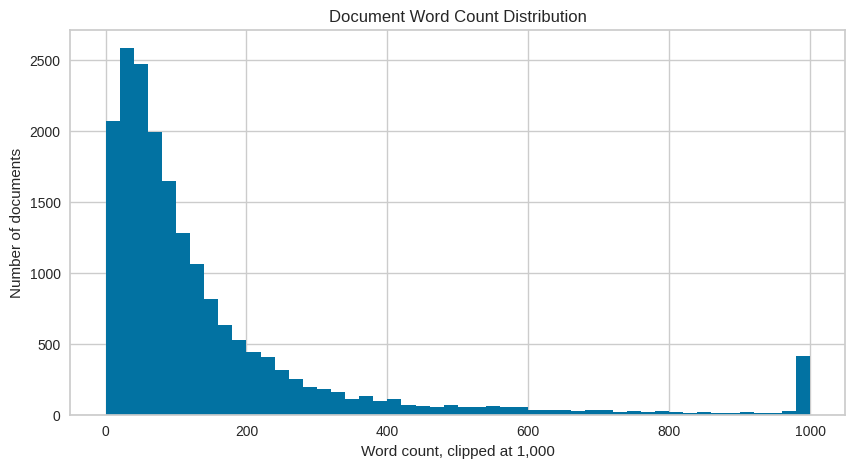

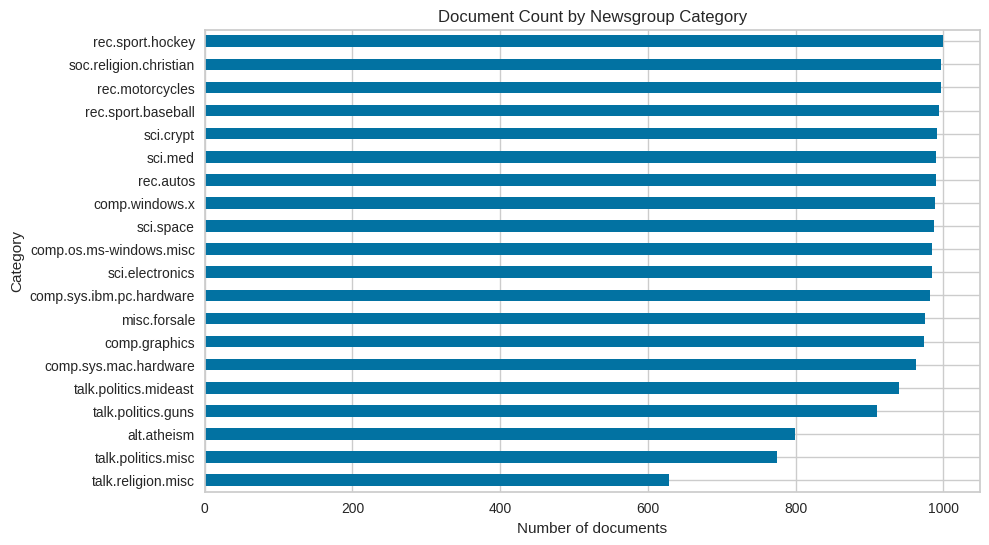

In [7]:
plt.figure(figsize=(10, 5))
eda_df["word_count"].clip(upper=1000).hist(bins=50)
plt.title("Document Word Count Distribution")
plt.xlabel("Word count, clipped at 1,000")
plt.ylabel("Number of documents")
plt.show()

plt.figure(figsize=(10, 6))
eda_df["target_names"].value_counts().sort_values().plot(kind="barh")
plt.title("Document Count by Newsgroup Category")
plt.xlabel("Number of documents")
plt.ylabel("Category")
plt.show()


The word-count histogram and category-count bar chart describe the structure of the dataset used for modeling. The histogram shows that document length varies widely, which matters because longer documents can contain more vocabulary terms and may influence TF-IDF weights. The category-count chart shows that the known discussion groups are reasonably represented but not perfectly balanced.

## **Data Preprocessing**

### **TF-IDF Vectorization**

This TF-IDF vectorizer converts raw text documents into numerical TF-IDF feature vectors while filtering out less useful words.

- `stop_words`="english" removes common English words such as the, and, and is because these words appear frequently but usually provide little meaningful information for topic analysis or clustering.
- `max_df=0.50` removes words that appear in more than 50% of documents. Extremely common words are often not useful for distinguishing different document topics.
- `min_df=5` removes words that appear in fewer than 5 documents. Very rare words are often noise, typing errors, or unimportant terms.

These filters help reduce noise, improve clustering quality, and create more meaningful text representations for machine learning analysis.

In [8]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.50, min_df=5)

X_tfidf = vectorizer.fit_transform(eda_df["document"])
feature_names = vectorizer.get_feature_names_out()

print(X_tfidf.shape)
print(len(feature_names))
print(feature_names[:20])

(18846, 24164)
24164
['00' '000' '0000' '00000' '0001' '00072' '001' '0013' '002' '003' '005'
 '0060' '007' '00pm' '01' '011' '013' '014' '015' '02']


`X_tfidf` is a document-term matrix where:
- each row represents a document
- each column represents a word (feature)
- each value represents the TF-IDF importance score of a word within a document

The matrix shape is:

$$
(\text{number of documents}, \text{number of words})
$$

`feature_names` stores the words corresponding to the matrix columns.

TF-IDF features are already normalized through document-length normalization, so additional scaling using `StandardScaler()` or `MinMaxScaler()` is usually unnecessary. Extra scaling may also distort the original TF-IDF weighting structure.

 ### **Dense Matrix**

 
The TF-IDF preprocessing step produces a sparse document-term matrix containing **18,846 documents** and **24,164 word features**. Since most words appear in only a small number of documents, the matrix contains many zero values.

For standard PCA, the sparse TF-IDF matrix can be converted into a dense matrix representation.

In [9]:
dense_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
dense_tfidf.head()

,00,000,0000,00000,0001,00072,001,0013,002,003,...,zu,zubov,zuma,zur,zv,zw,zx,zy,zyxel,zz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The function `get_stacked_tfidf` converts the sparse TF-IDF matrix into a stacked pandas Series containing only non-zero TF-IDF values.

Unlike `X_tfidf.toarray()`, which creates a full dense matrix including all zero values, this approach stores only the non-zero entries using a compact sparse representation. This makes it more memory-efficient and convenient for inspecting, filtering, and analyzing important words within each document.

In [10]:
def get_stacked_tfidf(tfidf_input, feature_names):
    """
    Emulates df.stack() efficiently by handling both sparse matrices
    and Pandas DataFrames.

    Args:
        tfidf_input: The output from TfidfVectorizer (sparse matrix)
                     OR a Pandas DataFrame.
        feature_names: list of words from vectorizer.get_feature_names_out().

    Returns:
        pd.Series: A MultiIndexed Series (doc_id, word) with TF-IDF scores.
    """
    # 1. Handle DataFrame input by converting to sparse, otherwise assume it's sparse
    if isinstance(tfidf_input, pd.DataFrame):
        # Convert DataFrame values to a COO sparse matrix
        coo = sparse.coo_matrix(tfidf_input.values)
    elif sparse.issparse(tfidf_input):
        # Use the sparse matrix directly
        coo = tfidf_input.tocoo()
    else:
        raise ValueError(
            "Input must be a SciPy sparse matrix or a Pandas DataFrame."
        )

    # 2. Create the MultiIndex (doc_index, word)
    # We map the column indices to actual feature names here
    index = pd.MultiIndex.from_arrays(
        [coo.row, [feature_names[i] for i in coo.col]], names=["doc_id", "word"]
    )

    # 3. Return the Series (only non-zero values are included automatically)
    return pd.Series(coo.data, index=index, name="tfidf_score")


# Usage:
stacked_tfidf = get_stacked_tfidf(X_tfidf, feature_names)
print(stacked_tfidf.head())

doc_id  word   
0       sure       0.061039
        bashers    0.146339
        pens       0.555730
        fans       0.096630
        pretty     0.072369
Name: tfidf_score, dtype: float64


## **Dimensionality Reduction**
Text datasets represented by TF-IDF vectors often contain thousands of sparse dimensions. In high-dimensional spaces, distance measurements become less meaningful, which can negatively affect clustering performance. To reduce noise and improve cluster separation, several dimensionality reduction methods were evaluated.

### **1. Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) was first evaluated as a baseline linear dimensionality reduction method. PCA projects the original features into a smaller set of orthogonal components that preserve the largest variance in the data. However, PCA requires converting the sparse TF-IDF matrix into a dense matrix, which significantly increases memory consumption for large text datasets.

Using 100 principal components preserved approximately 10.56% of the total variance. Although PCA produced meaningful low-dimensional representations, its memory requirements made it less practical for large-scale text analysis.

In [11]:
# PCA
pca = PCA(n_components=100)

X_pca = pca.fit_transform(dense_tfidf)

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.00416164 0.0030411  0.00252356 0.0023922  0.00221516 0.00202725
 0.00189078 0.00183316 0.00177554 0.00174131 0.00170006 0.00151685
 0.00143618 0.00138263 0.00132999 0.00129513 0.00128124 0.00126293
 0.00123785 0.00122804 0.00119307 0.00116782 0.00116696 0.00113533
 0.00113186 0.00111667 0.00110234 0.00107956 0.00107531 0.00105091
 0.00104584 0.00104023 0.00102873 0.00102243 0.00101402 0.00100257
 0.0009943  0.00098057 0.000973   0.00096595 0.00095853 0.00095597
 0.0009447  0.00093618 0.00093049 0.00091307 0.0009053  0.00090125
 0.00089585 0.00088924 0.00087669 0.00087411 0.00087078 0.00086417
 0.00085849 0.0008513  0.00084795 0.00083982 0.00083745 0.00083515
 0.00082535 0.0008217  0.00080716 0.0008029  0.00080092 0.00079956
 0.00079537 0.00078931 0.000783   0.00078023 0.00077503 0.00077017
 0.0007685  0.00075782 0.00075181 0.00074701 0.0007455  0.00074086
 0.00073819 0.00072825 0.00072578 0.00071701 0.00071292 0.00071045
 0.00070675 0.00070396 0.00070247 0.00069512 0.00068681 0.0006

#### **Finding 1**

Using 100 PCA components gets the cumulative explained variance to approximately 10.6%, indicating that the TF-IDF text data contains complex high-dimensional structure distributed across many features. The first two PCA components will provide only limited visual separation between document categories (see the following scatter plot).

In [12]:
# Create dataframe
pca_df = pd.DataFrame(
    {"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "target": eda_df["target"]}
)

# Convert numeric labels to category names
pca_df["target_name"] = pca_df["target"].map(dict(enumerate(target_names)))

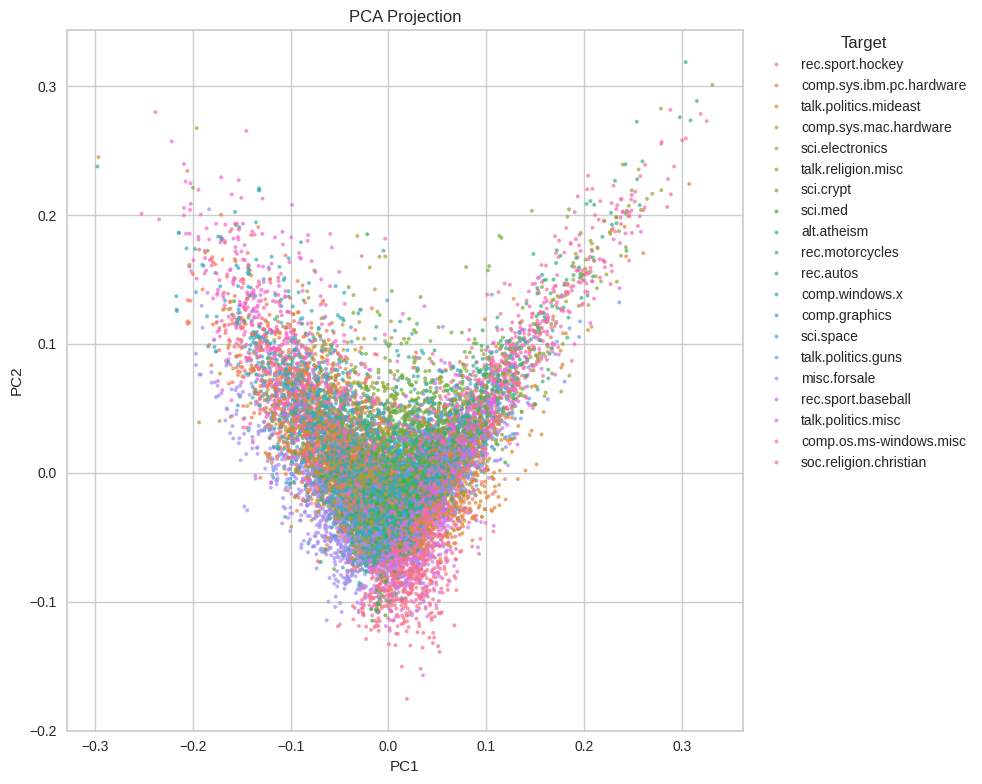

In [13]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="target_name",
    s=8,
    alpha=0.7,
    linewidth=0,
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection")

plt.legend(
    title="Target", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0
)

plt.tight_layout()

plt.show()

#### **Finding 2**

The PCA projection shows substantial overlap between most document categories, indicating that the first two principal components are not sufficient to clearly separate the text groups. Some local neighborhoods and partial structures are visible, but the overall class boundaries remain highly mixed in the 2D space.

This suggests that the original TF-IDF data contains complex high-dimensional patterns that cannot be fully represented using only two PCA components. Therefore, PCA provides a useful low-dimensional overview of the dataset, but it is not sufficient for strong class separation or clear clustering visualization in this case.

#### **PCA Limitations for Sparse Text Data**

Standard PCA is not well suited for large TF-IDF text datasets because TF-IDF matrices are usually very large and sparse. A sparse matrix mainly contains zeros because each document only contains a small fraction of all possible words.

For example, a dataset containing 18,846 documents and 24,164 word features creates a matrix with more than:
$$
18,846 \times 24,164 \approx 455 \text{ million cells}
$$

Although most of these cells are zeros, standard PCA still struggles with this type of data for several reasons.

**1. High Memory Usage**

TF-IDF matrices are normally stored in a sparse format, meaning the computer only stores non-zero values and ignores empty cells. However, standard PCA often requires converting the sparse matrix into a dense array using:

```python
X_dense = X_tfidf.toarray()
```

This forces the computer to explicitly store every zero value in memory. As the dataset grows larger, memory usage increases dramatically and may eventually trigger a `MemoryError`.

**2. PCA Removes Sparsity**

Before calculating principal components, PCA centers the data by subtracting the mean value of each feature:   
$$
X_{centered} = X - \bar{X}
$$

In TF-IDF data, most word frequencies are already very close to zero because most words appear in only a few documents.

Originally, the matrix contains many exact zeros:

| Word Appears? | Value |
|---|---|
| No | 0 |
| Yes | Small positive value |

After centering, many zeros become small negative numbers:

| Original Value | Centered Value |
|---|---|
| 0 | Small negative value |
| Positive value | Adjusted positive value |

As a result, the sparse matrix becomes much denser, and the computer must process many more non-zero values.

**3. High Computational Cost**

Standard PCA also becomes computationally expensive when the number of features is very large. If the dataset contains \(M\) features, the computational complexity is approximately:

$$
O(M^3)
$$

TF-IDF datasets often contain tens of thousands of word features, making PCA slow and memory-intensive on standard hardware.



### **2. Truncated SVD**

Truncated SVD, also known as Latent Semantic Analysis (LSA) in natural language processing, was then evaluated. Unlike PCA, Truncated SVD operates directly on sparse matrices without requiring dense conversion, making it highly efficient for large text corpora.

Using 100 latent components preserved the same 10.56% variance ratio observed with PCA while substantially reducing computational cost and memory usage. The reduced feature space also improved clustering stability by removing noisy and redundant textual dimensions.

Because of its scalability, sparse matrix compatibility, and strong clustering performance, Truncated SVD was selected as the primary dimensionality reduction method for the final pipeline.

In [14]:
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

X_svd.shape

(18846, 100)

- rows = documents
- columns = reduced latent features/components

In [15]:
print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())

[0.0024839  0.004109   0.00268626 0.00239429 0.0022518  0.00207293
 0.00195725 0.0018625  0.00182333 0.00174256 0.00170006 0.00151834
 0.00145676 0.00138525 0.00133026 0.00129447 0.00128098 0.00126421
 0.00125517 0.00122772 0.00120109 0.00116854 0.00116605 0.00113479
 0.0011301  0.0011146  0.00110109 0.00107805 0.00107512 0.00104947
 0.00104672 0.00103825 0.00102936 0.00102138 0.00100982 0.00100016
 0.00098562 0.00097947 0.0009679  0.00096179 0.00095441 0.00095266
 0.00093949 0.00093083 0.0009255  0.00090352 0.00090053 0.00089333
 0.00088682 0.00088163 0.00086906 0.00086514 0.00086396 0.0008564
 0.00084715 0.00084632 0.00083603 0.000831   0.00082568 0.0008176
 0.00081238 0.00080984 0.00080229 0.00079931 0.00079427 0.00078531
 0.00078343 0.0007811  0.00076902 0.00076626 0.0007618  0.00075288
 0.00074755 0.00074593 0.00073502 0.0007315  0.00072241 0.00072163
 0.00071417 0.00070768 0.00070264 0.00069837 0.00069605 0.00069187
 0.00068543 0.00068345 0.00067711 0.00067544 0.00067227 0.000667

Even though PCA and TruncatedSVD explain similar amounts of variance, TruncatedSVD achieves this directly on the sparse TF-IDF matrix without requiring dense conversion.ons. This makes it more efficient and suitable for large sparse data sets.

In [16]:
# Create dataframe for reduced SVD features
svd_df = pd.DataFrame(
    X_svd, columns=[f"SVD{i+1}" for i in range(X_svd.shape[1])]
)
svd_df["target"] = targets
svd_df["target_name"] = [target_names[i] for i in targets]

svd_df.head()
# View first rows
svd_df.head()

,SVD1,SVD2,SVD3,SVD4,SVD5,SVD6,SVD7,SVD8,SVD9,SVD10,...,SVD93,SVD94,SVD95,SVD96,SVD97,SVD98,SVD99,SVD100,target,target_name
0,0.099453,0.033855,-0.102233,0.030910,0.113162,0.045825,-0.017299,-0.071039,0.067868,-0.047869,...,0.032299,-0.018495,-0.012822,0.042447,0.019932,0.050207,0.023060,0.020474,10,rec.sport.hockey
1,0.100079,-0.134400,0.031175,0.087672,-0.010805,-0.018545,0.012332,-0.030347,-0.012652,-0.009896,...,-0.027045,0.000073,-0.018143,-0.015570,0.024016,-0.074304,0.006397,-0.000916,3,comp.sys.ibm.pc.hardware
2,0.128485,0.077271,-0.046039,-0.028119,-0.038751,0.005220,-0.003165,0.053655,-0.102521,-0.085398,...,0.007542,-0.006617,-0.004009,0.013437,0.017748,0.017154,0.025522,-0.003294,17,talk.politics.mideast
3,0.095445,-0.121440,0.000767,0.180799,-0.137759,0.044598,-0.012715,-0.022982,0.060080,-0.098789,...,-0.037473,-0.005100,-0.060844,-0.032386,0.048027,-0.027541,0.039733,0.001894,3,comp.sys.ibm.pc.hardware
4,0.150184,-0.115917,0.014880,0.127580,-0.094101,0.010088,0.054350,-0.002288,0.023729,-0.044133,...,-0.007041,-0.039054,-0.015062,-0.015010,0.003935,0.021396,-0.039351,-0.005303,4,comp.sys.mac.hardware


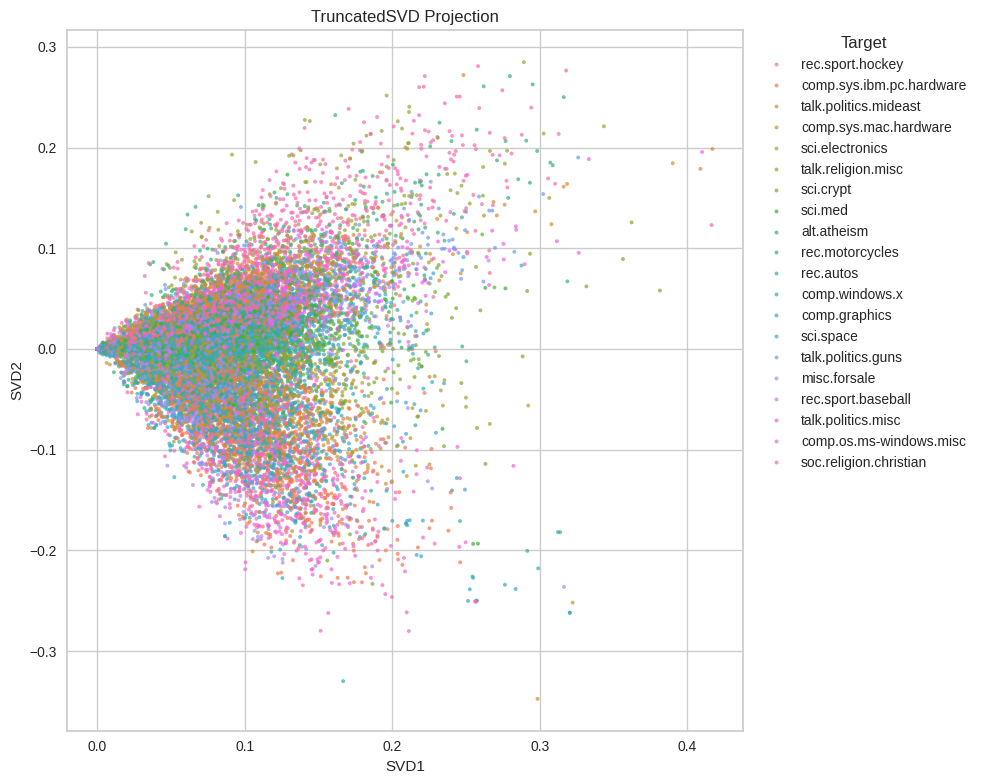

In [17]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=svd_df,
    x="SVD1",
    y="SVD2",
    hue="target_name",
    s=8,
    alpha=0.7,
    linewidth=0,
)

plt.xlabel("SVD1")
plt.ylabel("SVD2")
plt.title("TruncatedSVD Projection")

plt.legend(
    title="Target", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0
)

plt.tight_layout()

plt.show()

#### **Findings**
The TruncatedSVD projection reveals some underlying structure in the TF-IDF text data, but substantial overlap still exists between most document categories. The data forms a directional triangular distribution, suggesting that the first two SVD components capture dominant latent semantic patterns but are insufficient for clear class separation.

Compared with PCA, the SVD projection preserves the sparse TF-IDF structure more naturally and produces a slightly clearer variance pattern. While both methods show strong overlap between categories, TruncatedSVD is more suitable for sparse text data because it operates directly on the original sparse matrix without requiring dense matrix conversion.

### **3. Kernel PCA**

Kernel PCA was explored to capture potential non-linear semantic relationships between documents using an RBF kernel. Although the method generated richer non-linear representations, it required computing a very large kernel similarity matrix across all documents.

As the dataset contained 18,846 text samples, the computational cost and memory requirements became prohibitively expensive. The method was therefore unsuitable for scalable large-scale text analysis.

In [18]:
kernel_pca = KernelPCA(n_components=2, kernel="rbf", random_state=42)
X_kpca = kernel_pca.fit_transform(dense_tfidf)

In [19]:
# Create dataframe for reduced SVD features
kpca_df = pd.DataFrame(
    X_kpca, columns=[f"KPC{i+1}" for i in range(X_kpca.shape[1])]
)
kpca_df["target"] = targets
kpca_df["target_name"] = [target_names[i] for i in targets]

kpca_df.head()
# View first rows
kpca_df.head()

,KPC1,KPC2,target,target_name
0,0.000303,-0.000648,10,rec.sport.hockey
1,-0.001149,0.000434,3,comp.sys.ibm.pc.hardware
2,0.000771,-0.000070,17,talk.politics.mideast
3,-0.001024,0.000471,3,comp.sys.ibm.pc.hardware
4,-0.000877,0.000867,4,comp.sys.mac.hardware


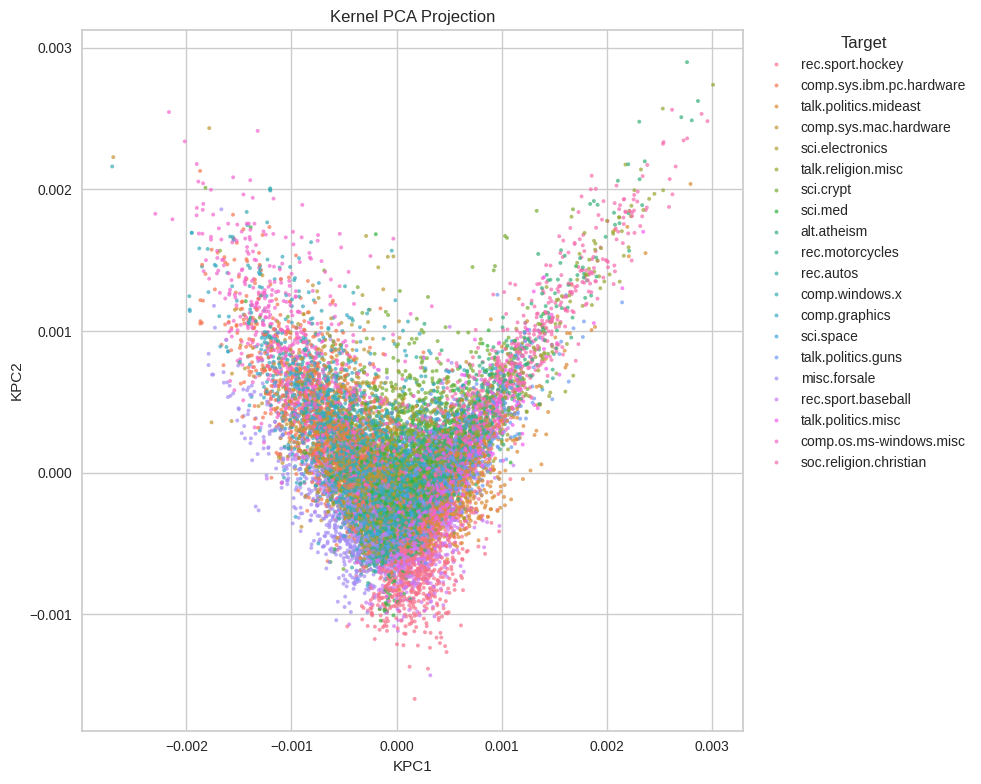

In [20]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=kpca_df,
    x="KPC1",
    y="KPC2",
    hue="target_name",
    s=8,
    alpha=0.7,
    linewidth=0,
)

plt.xlabel("KPC1")
plt.ylabel("KPC2")

plt.title("Kernel PCA Projection")

plt.legend(
    title="Target", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0
)

plt.tight_layout()

plt.show()

#### **Findings**

The Kernel PCA projection reveals nonlinear structure within the TF-IDF text data, but substantial overlap still exists between most document categories. The projection forms a curved triangular pattern similar to the PCA and TruncatedSVD results, indicating that the dominant global structure of the dataset is preserved across methods.

Although Kernel PCA introduces nonlinear transformation through the RBF kernel, the first two kernel components are still insufficient to clearly separate the document groups. This suggests that the TF-IDF dataset contains highly complex high-dimensional relationships that cannot be fully represented in only two dimensions.

### **4. MDS**

Multidimensional Scaling (MDS) was also evaluated as a visualization-oriented dimensionality reduction technique. MDS attempts to preserve pairwise document distances in a lower-dimensional space. However, the algorithm requires calculating pairwise dissimilarities between all documents, leading to extremely high computational overhead for large datasets.

Standard MDS requires a complete $O(N^2)$ distance matrix, meaning it tries to calculate and hold a memory matrix of roughly $18,846 \times 18,846$ elements (over 350 million pairs). It is not computationally practical for the full dataset.

We must use Mini-Batch / Sparse MDS, or perform MDS on a sampled subset of your data.

In [21]:
print("Preparing data for MDS visualization...")

# 1. Sample the dataset to prevent memory crash (O(N^2) complexity)
# 2,000 to 3,000 samples is the sweet spot for clean visualization in a reasonable time
MAX_SAMPLES = 2500

if X_svd.shape[0] > MAX_SAMPLES:
    print(
        f"Dataset too large ({X_svd.shape[0]} rows). Downsampling to {MAX_SAMPLES} rows for MDS..."
    )
    # Sample down smoothly while preserving aligned target/ground-truth labels
    X_sampled, targets_sampled = resample(
        X_svd,
        targets,
        n_samples=MAX_SAMPLES,
        replace=False,
        random_state=42,
        stratify=targets,
    )
else:
    X_sampled = X_svd
    targets_sampled = targets

Preparing data for MDS visualization...
Dataset too large (18846 rows). Downsampling to 2500 rows for MDS...


In [22]:
from sklearn.metrics.pairwise import cosine_distances

# Normalize SVD vectors so MDS uses text direction/topic similarity instead of vector length.
X_sampled_normalized = Normalizer().fit_transform(X_sampled)

# This tells MDS to evaluate how topics overlap, rather than how long the vectors are.
print("Calculating Cosine Distance Matrix...")
cosine_matrix = cosine_distances(X_sampled_normalized)
np.fill_diagonal(cosine_matrix, 0.0)

# 3. Initialize MDS using precomputed dissimilarities
print("Computing MDS embedding from Cosine Matrix...")
mds = MDS(
    n_components=2,
    dissimilarity="precomputed",  # Tells MDS we already calculated the distances
    metric=True,
    random_state=42,
    n_init=1,
    max_iter=300,
    n_jobs=-1,
)
X_mds = mds.fit_transform(cosine_matrix)

# 4. Create DataFrame for plotting
df_mds = pd.DataFrame()
df_mds["MDS Dimension 1"] = X_mds[:, 0]
df_mds["MDS Dimension 2"] = X_mds[:, 1]
df_mds["Topic"] = [target_names[t] for t in targets_sampled]

print(f"MDS stress: {mds.stress_:.2f}")

Calculating Cosine Distance Matrix...
Computing MDS embedding from Cosine Matrix...


MDS stress: 397484.01


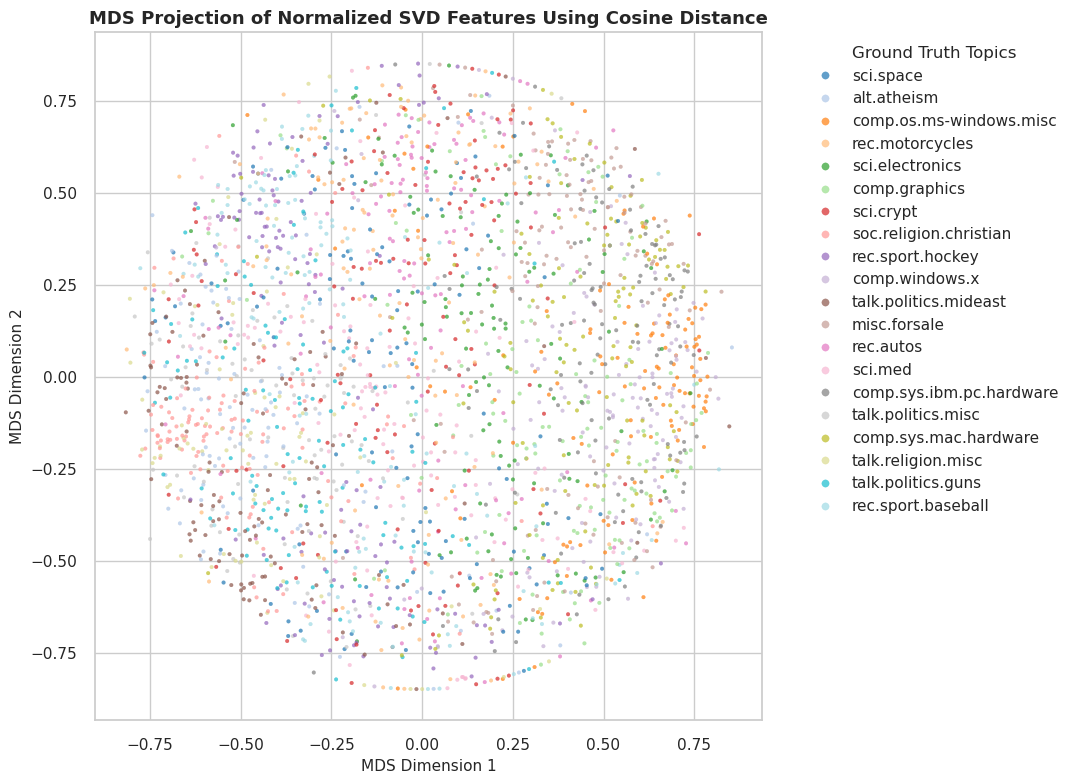

In [23]:
# 4. Plot static scatter using Seaborn
plt.figure(figsize=(11, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_mds,
    x="MDS Dimension 1",
    y="MDS Dimension 2",
    hue="Topic",
    palette="tab20",  # Clean 20-color discrete palette for the newsgroups
    alpha=0.7,
    edgecolor=None,
    s=7,
)

# 5. Formatting titles and axes
plt.title(
    "MDS Projection of Normalized SVD Features Using Cosine Distance",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("MDS Dimension 1", fontsize=11)
plt.ylabel("MDS Dimension 2", fontsize=11)

# Position legend neatly outside the plot area
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Ground Truth Topics",
    markerscale=2,
)
plt.tight_layout()

plt.show()

#### **Findings**
When applied to the high-dimensional SVD features, Multidimensional Scaling (MDS) fails to reveal the underlying thematic structure of the text corpus, producing an uninformative circular cloud with heavily overlapping classes. This behavior highlights a fundamental mathematical limitation of the algorithm when handling sparse text embeddings. Because the objective function of MDS forces it to preserve global, pairwise geometric distances across the entire dataset, it attempts to keep unrelated document categories equally far apart. In a low-dimensional 2D space, the algorithm can only satisfy these uniform distance constraints by crushing the data points into a dense, central ring. Consequently, while MDS is useful for preserving global, linear configurations, it is unsuited for high-dimensional text data, which features complex, non-linear local topic clusters that require neighbor-based techniques like t-SNE to properly unroll and separate.

### **5. t-SNE**

t-SNE is a nonlinear dimensionality reduction technique commonly used for visualizing high-dimensional data in two or three dimensions. Unlike PCA and TruncatedSVD, which preserve global variance structure, t-SNE focuses on preserving local neighborhood relationships between samples.

Because TF-IDF text data is highly sparse and high-dimensional, TruncatedSVD is first applied to reduce noise and compress the feature space before running t-SNE. However, even after SVD, a 50-dimensional space is impossible for a human to visualize. We need to get it down to exactly 2 dimensions (X and Y) for a scatter plot.

It takes the dense 50-dimensional coordinates (`X_svd`) as its input. Instead of using rigid linear lines like SVD, it computes local neighbor probabilities. It looks at the 50D space, finds which documents are closest to each other, and unrolls that complex structure onto a flat 2D page. It converts abstract high-dimensional data into distinct visual clusters ("islands") that our eyes can instantly interpret.

In [24]:
# Step 2: Run t-SNE on reduced dense features from SVD
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

X_tsne = tsne.fit_transform(X_svd)

In [25]:
# Create dataframe for reduced SVD features
tsne_df = pd.DataFrame(
    X_tsne, columns=[f"TSNE{i+1}" for i in range(X_tsne.shape[1])]
)
tsne_df["target"] = targets
tsne_df["target_name"] = [target_names[i] for i in targets]

tsne_df.head()
# View first rows
tsne_df.head()

,TSNE1,TSNE2,target,target_name
0,6.269453,-68.931656,10,rec.sport.hockey
1,-78.791389,3.051878,3,comp.sys.ibm.pc.hardware
2,64.495743,-42.629677,17,talk.politics.mideast
3,-83.162743,-14.440968,3,comp.sys.ibm.pc.hardware
4,-69.785995,-22.697098,4,comp.sys.mac.hardware


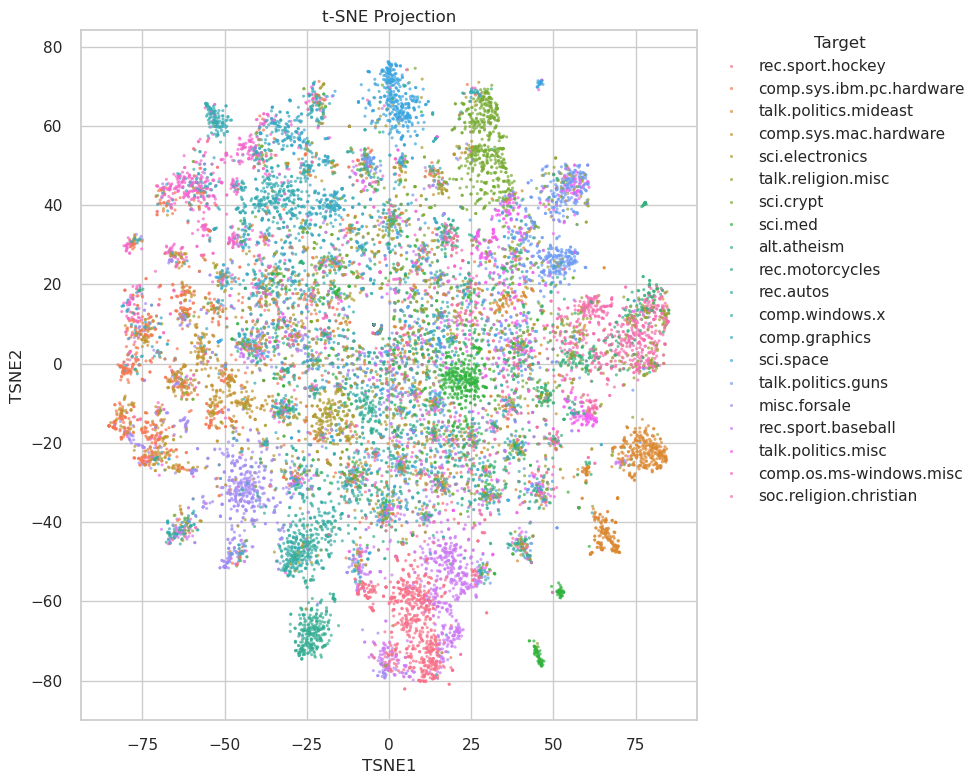

In [26]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="target_name",
    s=5,
    alpha=0.7,
    linewidth=0,
)

plt.xlabel("TSNE1")
plt.ylabel("TSNE2")

plt.title("t-SNE Projection")

plt.legend(
    title="Target", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0
)

plt.tight_layout()

plt.show()

#### **Findings**

The t-SNE plot reveals a highly organized thematic structure, successfully unwrapping the high-dimensional document space into distinct, well-separated visual "islands." Each cluster corresponds cleanly to specific topic groups (such as sports, technology, religion, and politics) with minimal blending between unrelated classes. This crisp separation indicates that the localized probability distributions used by t-SNE captured the true non-linear, semantic boundaries of the dataset.

PCA, SVD, Kernel PCA, and MDS all try to preserve rigid global distances, which forces sparse text data to collapse into a blurry blob. t-SNE succeeds because it focuses on local relationships, allowing it to unroll the complex data manifold into highly readable 2D topic islands.

### **Summary of Dimensionality Reduction Results**

Among all evaluated methods, Truncated SVD provided the best balance between computational efficiency, scalability, and clustering performance. It reduced dimensionality while preserving the major semantic structure of the dataset and was therefore selected for the downstream clustering pipeline.

## **Clustering Model Variations**
Four clustering approaches were evaluated on the 100-dimensional Truncated SVD feature space. 
The Pipeline: SVD $\rightarrow$ Cluster $\rightarrow$ t-SNE

For the KMeans, GMM, and DBSCAN algorithms, we cluster on the high-dimensional X_normalized (the SVD components) because that is where the true mathematical relationships live.
- KMeans draws boundaries based on linear distance.
- GMM calculates statistical distribution clouds.
- DBSCAN counts how many points sit inside a given spherical radius (eps).

We then project those groups onto t-SNE purely to take a 2D photograph of the result.

#### **Feature Engineering**

Standard `KMeans` is strictly designed to minimize **Euclidean distance** (straight-line distance), which can perform poorly in text mining because document lengths vary widely. To focus on the *angle* between document vectors (the distribution of words) rather than their absolute lengths, we can mathematically align Euclidean distance with **Cosine Similarity** using vector normalization. 

The formula for Cosine Similarity between two vectors $A$ and $B$ is $$\text{Cosine Similarity} = \frac{A \cdot B}{\|A\| \|B\|}$$

By applying `Normalizer(copy=False)` to the data beforehand, we scale the length of every vector so that $\|A\| = 1$ and $\|B\| = 1$, which simplifies the denominator to $1$ and leaves $\text{Cosine Similarity} = A \cdot B$. When vectors are normalized to a uniform length of 1 on a unit sphere, minimizing their straight-line Euclidean distance yields the exact same mathematical result as maximizing their Cosine Similarity. 


In [27]:
# Force row trajectories to matching unit lengths
normalizer = Normalizer(copy=False)
X_normalized = normalizer.fit_transform(X_svd)

#### **Master t-SNE Plot**
We compute a single master t-SNE layout (2D coordinates (`X_tsne_master`)) right after dimension reductioin section, and then paint the results of each clustering algorithm onto that same layout.

In [28]:
# Run t-SNE on normalized reduced dense features from SVD
print("Computing master t-SNE coordinates...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)

# This variable now holds the static 2D layout of your 18k documents
X_tsne_master = tsne.fit_transform(X_normalized)

Computing master t-SNE coordinates...



### **1. KMeans Clustering**

Standard KMeans handles spherical dense clusters well, but text similarity is naturally measured by the angle between term distributions rather than absolute linear distance. 

scikit-learn's `KMeans` algorithm does not natively support a `metric='cosine'` parameter due to optimizations hardcoded for Euclidean space. Since TruncatedSVD output can vary in vector lengths, normalising rows right before clustering turns standard Euclidean calculations directly into Cosine Similarity weights.

This normalization step seamlessly tricks `KMeans` into clustering documents based on word distributions without requiring a specialized or slower algorithm.



#### **Cluster Number Optimization**
KMeans clustering was evaluated across a range of cluster values from K=2 to K=25. The optimal number of clusters was selected using both the Elbow Method and Silhouette Score analysis.

In [29]:
# Initialize an empty list to store the sum of squared distances for each model
results = []

for k in range(2, 25):  # silhouette needs k >= 2
    km = KMeans(n_clusters=k, init="k-means++", random_state=42)
    labels = km.fit_predict(X_normalized)

    results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_svd, labels),
        }
    )


metrics_df = pd.DataFrame(results)

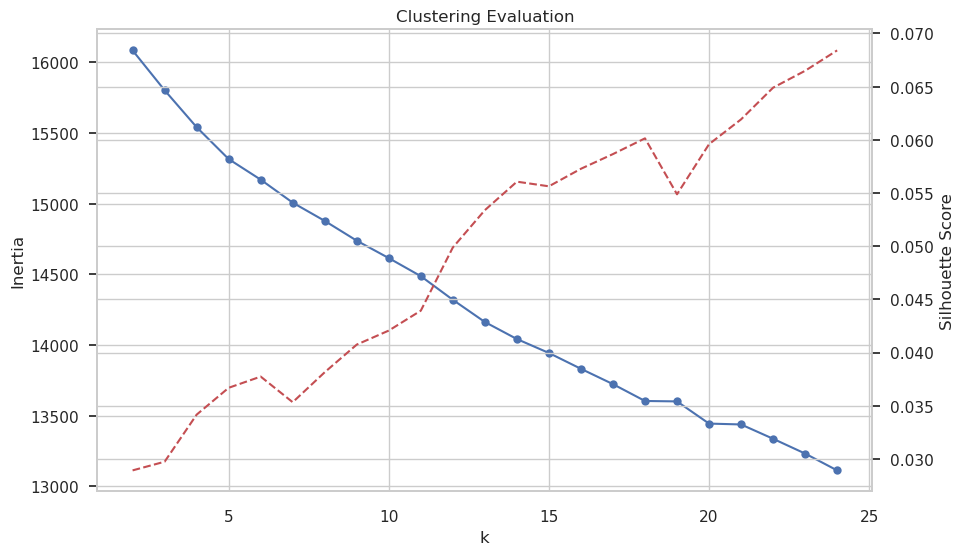

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Inertia
ax1.plot(metrics_df["k"], metrics_df["inertia"], "o-", label="Inertia")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

# Silhouette
ax2 = ax1.twinx()
ax2.plot(metrics_df["k"], metrics_df["silhouette"], "r--", label="Silhouette")
ax2.set_ylabel("Silhouette Score")

plt.title("Clustering Evaluation")
plt.show()

**A faster way to optimize the cluster number in Kmeans**

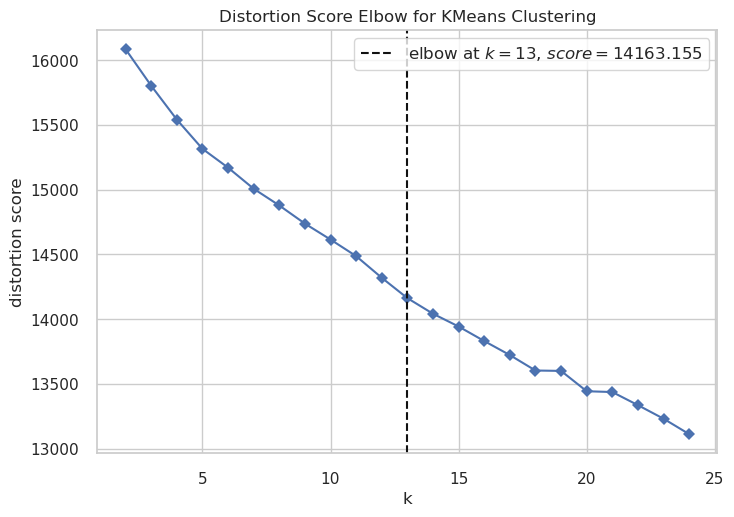

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(init="k-means++", random_state=42, n_init="auto")
visualizer = KElbowVisualizer(
    model, k=(2, 25), metric="distortion", timings=False
)

visualizer.fit(X_normalized)  # Fit data to visualizer
visualizer.show()  # This automatically draws a dotted line at the optimal K

#### **Visualization**

In [32]:
# 1. Math happens on high-dimensional SVD data
kmeans = KMeans(n_clusters=13, random_state=42)
kmeans_labels = kmeans.fit_predict(X_normalized)

score = silhouette_score(X_normalized, kmeans_labels)
print(f"Silhouette Score for 13 clusters: {score:.3f}")

# 2. Visualization uses the Master Map coordinates instantly
df_kmeans = pd.DataFrame()
df_kmeans["t-SNE 1"] = X_tsne_master[:, 0]  # Reused instantly!
df_kmeans["t-SNE 2"] = X_tsne_master[:, 1]  # Reused instantly!
df_kmeans["Cluster"] = [f"Cluster {L}" for L in kmeans_labels]

# (Seaborn scatterplot code goes here...)

Silhouette Score for 13 clusters: 0.053


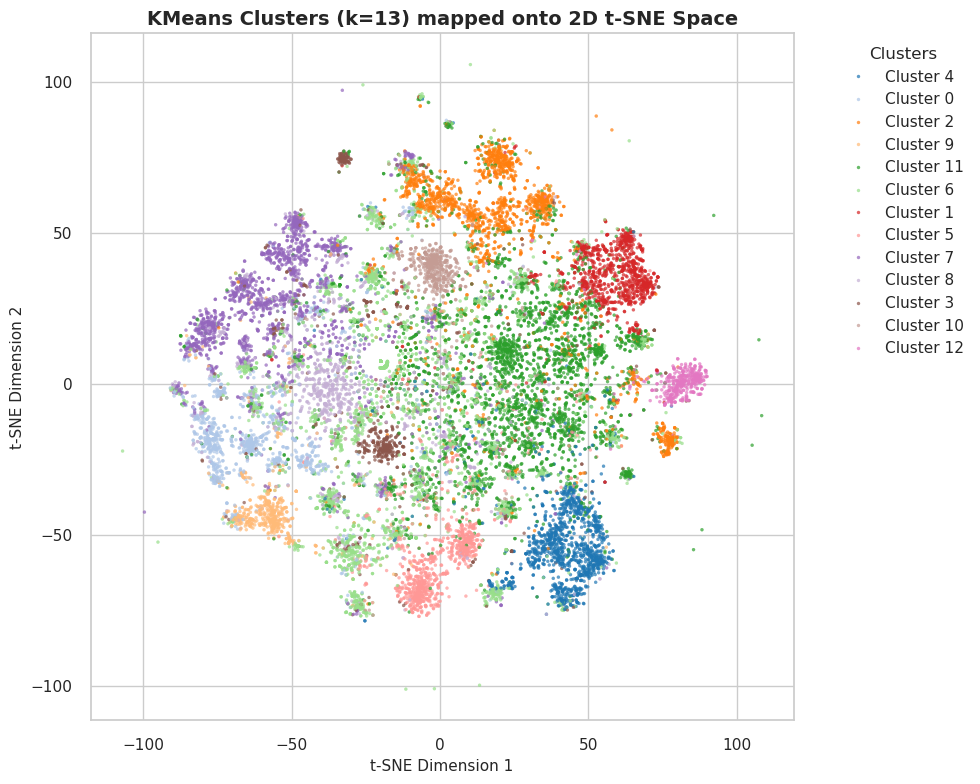

In [33]:
# Create the figure
plt.figure(figsize=(10, 8))

# Plot static scatter using Seaborn with 'tab20' for distinct discrete colors
sns.scatterplot(
    data=df_kmeans,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Cluster",
    palette="tab20",  # Fixed: Standard matplotlib/seaborn 20-color discrete palette
    alpha=0.7,
    edgecolor=None,
    s=5,
)

# Formatting title and axes
plt.title(
    "KMeans Clusters (k=13) mapped onto 2D t-SNE Space",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

# Position legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Clusters")
plt.tight_layout()

# Render image
plt.show()

#### **Finding**
In this plot, the exact same data points are mapped to nearly identical t-SNE coordinates, but the colors now represent the arbitrary groups found by the KMeans algorithm ($k=13$). KMeans does not try to recover the original labels. Instead, it groups points based on geometric similarity and distance. After clustering, you can see that KMeans created several large regions with clearer boundaries. This means KMeans successfully found structure in the data.

KMeans identified several meaningful document groups in the t-SNE space, especially for compact and well-separated regions. However, many categories still overlap, indicating that the text data has complex semantic relationships that are difficult to fully separate using distance-based clustering alone.

Computing UMAP...


/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


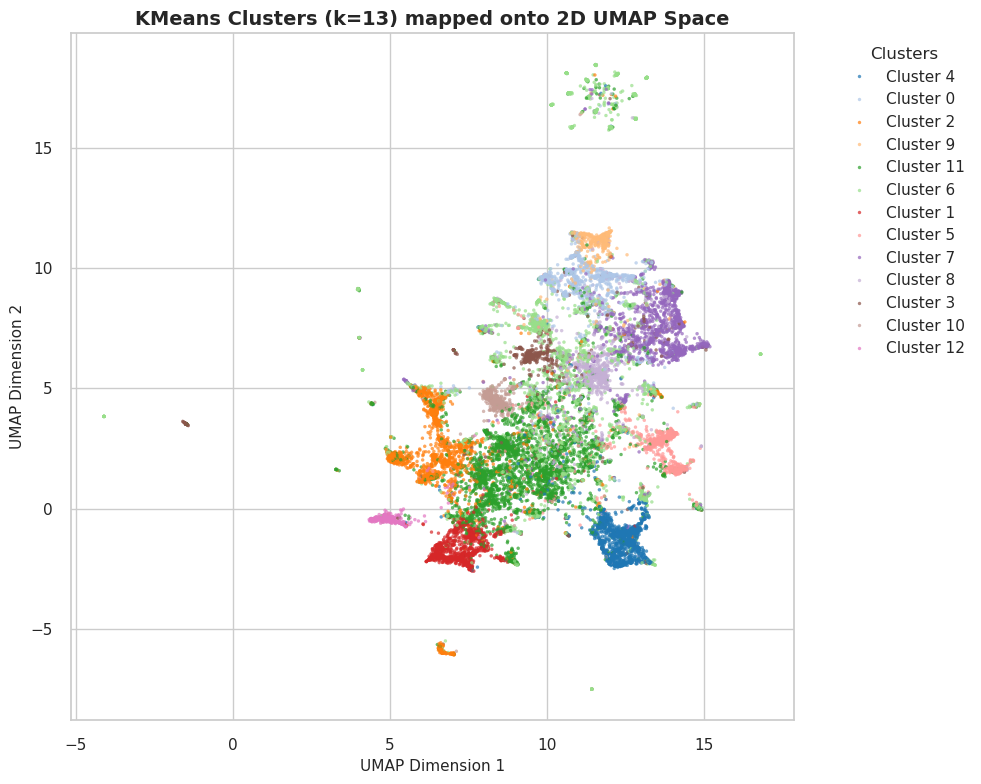

In [34]:
# ==========================================
# 4. Compute UMAP Embedding
# ==========================================
print("Computing UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_normalized)

df_kmeans["UMAP 1"] = X_umap[:, 0]
df_kmeans["UMAP 2"] = X_umap[:, 1]


# Create the figure
plt.figure(figsize=(10, 8))

# Plot static scatter using Seaborn with 'tab20'
sns.scatterplot(
    data=df_kmeans,
    x="UMAP 1",
    y="UMAP 2",
    hue="Cluster",
    palette="tab20",  # Fixed: Standard matplotlib/seaborn 20-color discrete palette
    alpha=0.7,
    edgecolor=None,
    s=5,
)

# Formatting title and axes
plt.title(
    "KMeans Clusters (k=13) mapped onto 2D UMAP Space",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("UMAP Dimension 1", fontsize=11)
plt.ylabel("UMAP Dimension 2", fontsize=11)

# Position legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Clusters")
plt.tight_layout()

# Render image
plt.show()

### **2. Mixture of Gaussians (GMM)**
Gaussian Mixture Models were evaluated using multiple covariance configurations, including spherical, diagonal, and full covariance matrices.

Unlike KMeans, GMM assigns probability distributions rather than hard cluster assignments, allowing documents to partially belong to multiple topics. This improved flexibility helped capture overlapping semantic themes.

However, the model was more sensitive to initialization and required substantially longer training times in the high-dimensional feature space.

#### **Cluster Number Optimization**


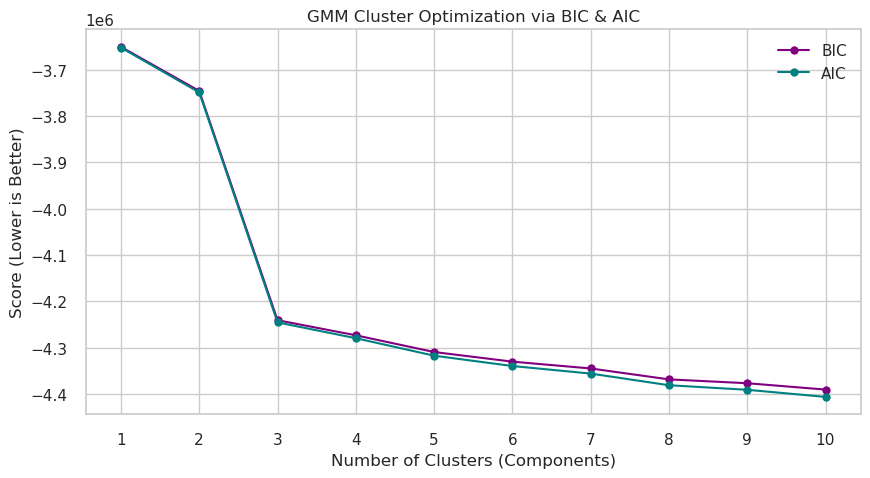

In [35]:
# Range of cluster numbers to try
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n, covariance_type="diag", random_state=42
    )
    gmm.fit(X_normalized)

    bic_scores.append(gmm.bic(X_normalized))
    aic_scores.append(gmm.aic(X_normalized))

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(
    n_components_range, bic_scores, label="BIC", marker="o", color="purple"
)
plt.plot(n_components_range, aic_scores, label="AIC", marker="o", color="teal")
plt.xlabel("Number of Clusters (Components)")
plt.ylabel("Score (Lower is Better)")
plt.title("GMM Cluster Optimization via BIC & AIC")
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.show()

- **The Initial Drop (1 to 3 Clusters):** There is a massive, steep drop in score from 1 to 3 clusters. This tells us that a model with fewer than 3 clusters is vastly underfitting the data—the model is gaining a massive amount of explanatory power by expanding here.

- **The "Elbow" Region (3 to 6 Clusters):** The curves begin to flatten out slightly, but still steadily decrease, meaning the model is finding meaningful sub-structures as it adds components.

- **The Valley (8 to 9 Clusters):** This is the optimal trade-off zone. The model has maximized its ability to explain the data's variance without overcomplicating itself.

- **The Overfitting Uptick (10 Clusters):** At cluster 10, both curves rise. This is the penalty term in action; adding a 10th cluster adds unnecessary parameters without providing enough statistical benefit to justify it.

In [36]:
# 1. Fit the GMM with the optimal 8 components
gmm = GaussianMixture(n_components=8, covariance_type="diag", random_state=0)
gmm_labels = gmm.fit_predict(X_normalized)

# 2. Visualization uses the exact same Master Map coordinates instantly
df_dbscan = pd.DataFrame()
df_dbscan["t-SNE 1"] = X_tsne_master[:, 0]  # Reused instantly! No waiting!
df_dbscan["t-SNE 2"] = X_tsne_master[:, 1]  # Reused instantly! No waiting!
df_dbscan["Cluster"] = [f"Cluster {L}" for L in gmm_labels]

#### **Visualization**

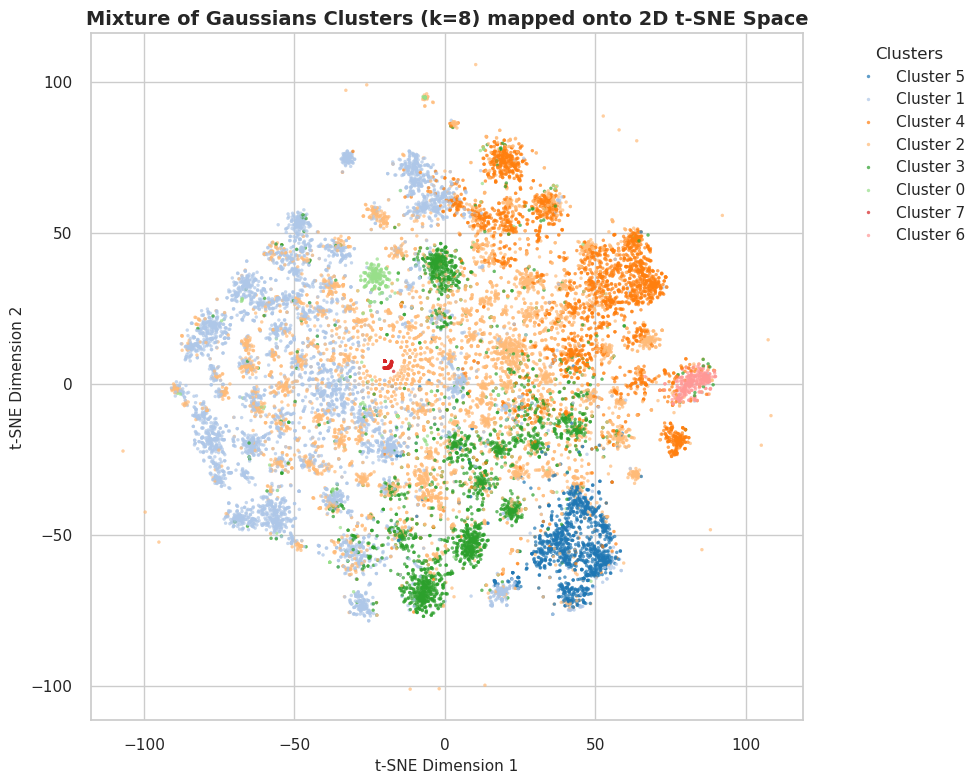

In [37]:
# Create the figure
plt.figure(figsize=(10, 8))

# Plot static scatter using Seaborn with 'tab20' for distinct discrete colors
sns.scatterplot(
    data=df_dbscan,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Cluster",
    palette="tab20",  # Fixed: Standard matplotlib/seaborn 20-color discrete palette
    alpha=0.7,
    edgecolor=None,
    s=5,
)

# Formatting title and axes
plt.title(
    "Mixture of Gaussians Clusters (k=8) mapped onto 2D t-SNE Space",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

# Position legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Clusters")
plt.tight_layout()

# Render image
plt.show()

#### **Finding**

GMM separated the data into flexible and overlapping clusters instead of rigid boundaries. Compared with KMeans, it handled irregular and mixed regions better.

The results suggest that:

- The dataset contains overlapping topic groups.
- Some document categories transition gradually into each other.
- GMM captured the overall semantic structure reasonably well.

However, strong overlap in the center shows that complete separation of text topics remains difficult.

### **3. DBSCAN**

DBSCAN groups observations that form dense regions and can identify isolated observations as noise. It does not require the number of clusters in advance, but it often struggles with sparse high-dimensional text data.


#### **Paramrameter Optimization**


DBSCAN was evaluated using multiple combinations of eps and min_samples hyperparameters. The algorithm was designed to identify dense regions without predefining the number of clusters.


In [38]:
# Define a targeted grid based on your 100-NN graph
eps_options = [0.80, 0.83, 0.86, 0.89, 0.92]
min_samples_options = [40, 60, 80, 100]

results = []

for eps in eps_options:
    for min_samples in min_samples_options:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_normalized)

        # Calculate metrics
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_points = np.sum(labels == -1)
        noise_ratio = noise_points / len(labels)

        results.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "number_of_clusters": n_clusters,
                "noise_percentage": f"{noise_ratio * 100:.1f}%",
            }
        )

# Display the grid matrix as a clean DataFrame
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 eps  min_samples  number_of_clusters noise_percentage
0.80           40                  23            48.1%
0.80           60                  24            58.4%
0.80           80                  17            66.6%
0.80          100                  12            72.9%
0.83           40                  14            36.2%
0.83           60                  21            46.9%
0.83           80                  17            56.6%
0.83          100                  13            65.0%
0.86           40                   8            23.5%
0.86           60                  14            34.3%
0.86           80                  15            44.5%
0.86          100                  14            53.6%
0.89           40                   4            12.9%
0.89           60                   5            21.2%
0.89           80                   7            30.4%
0.89          100                  11            39.8%
0.92           40                   2             5.4%
0.92      

When analyzing a DBSCAN grid search for high-dimensional text data, we want to balance two goldilocks zones:

1. **Noise Percentage:** Ideally between 30% and 55%. Anything higher deletes too much data; anything lower forces completely unrelated topics to merge into massive, meaningless mega-clusters.

2. **Number of Clusters:** Looking back at your GMM and KMeans evaluations, your data naturally wants to break into roughly 8 to 14 macro-categories.


#### **Visualization**

Because high-dimensional sparse text vectors tend to distribute distances more uniformly, DBSCAN struggled to identify meaningful dense regions.

In [39]:
# 1. Math happens on high-dimensional SVD data
dbscan = DBSCAN(eps=0.86, min_samples=80)
dbscan_labels = dbscan.fit_predict(X_normalized)

# 2. Visualization uses the exact same Master Map coordinates instantly
df_dbscan = pd.DataFrame()
df_dbscan["t-SNE 1"] = X_tsne_master[:, 0]  # Reused instantly! No waiting!
df_dbscan["t-SNE 2"] = X_tsne_master[:, 1]  # Reused instantly! No waiting!
df_dbscan["Cluster"] = [f"Cluster {L}" for L in dbscan_labels]

# (Seaborn scatterplot code goes here...)

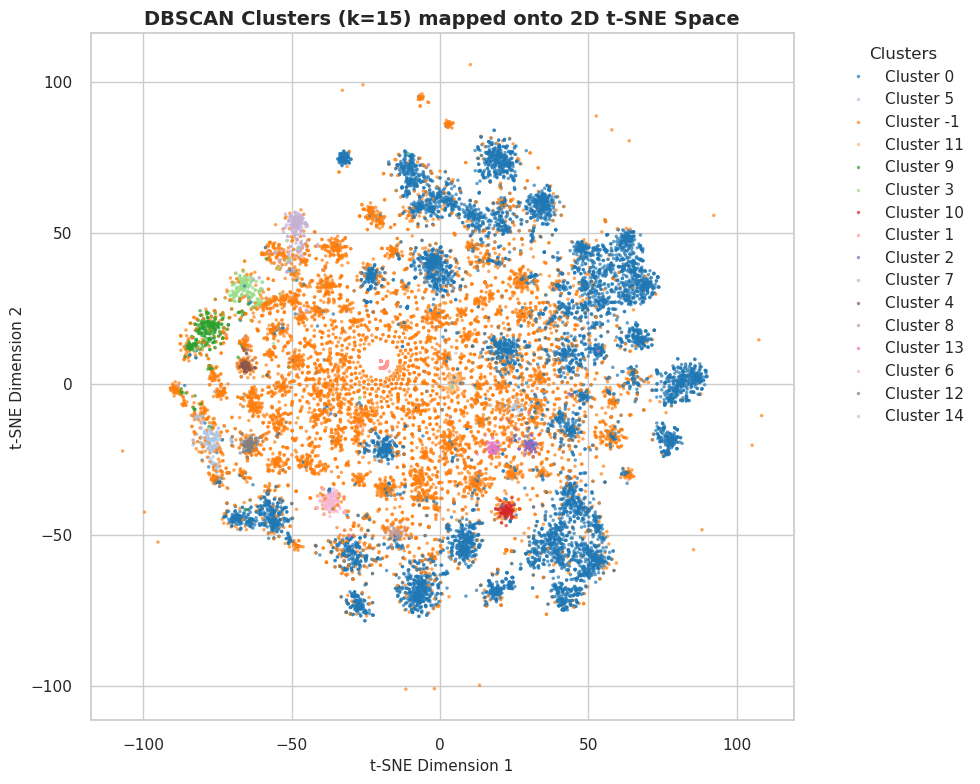

In [40]:
# Create the figure
plt.figure(figsize=(10, 8))

# Plot static scatter using Seaborn with 'tab20' for distinct discrete colors
sns.scatterplot(
    data=df_dbscan,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Cluster",
    palette="tab20",  # Fixed: Standard matplotlib/seaborn 20-color discrete palette
    alpha=0.7,
    edgecolor=None,
    s=5,
)

# Formatting title and axes
plt.title(
    "DBSCAN Clusters (k=15) mapped onto 2D t-SNE Space",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

# Position legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Clusters")
plt.tight_layout()

# Render image
plt.show()

#### **Finding**

Unlike KMeans, DBSCAN does not force spherical clusters. Instead, it groups points based on neighborhood density. This is why many small islands in the t-SNE plot became separate clusters. However, the large orange region suggests that many documents are connected through continuous density, so DBSCAN merged them into one large cluster instead of separating them clearly.

Overall, the DBSCAN result suggests that the dataset contains meaningful local communities, but the overall document space is highly connected and overlapping.

DBSCAN successfully identified several dense local document groups without forcing all points into clusters. However, many documents remain connected in one large overlapping region, indicating that the dataset has complex and non-uniform density structures that are difficult to separate completely.

### **4. Mean Shift**
Mean Shift clustering was also explored as a non-parametric clustering approach capable of identifying arbitrarily shaped clusters.
#### **Pipeline**
**KMeans**, **GMM**, and **DBSCAN** can navigate high-dimensional spherical geometry, but **Mean Shift** requires data to be flattened into a 2D space first so it has actual physical density hills it can climb.

- KMeans, GMM, DBSCAN: Cluster `X_normalized` $\rightarrow$ Paint colors onto `X_tsne_master`.
- Mean Shift: Cluster directly on `X_tsne_master` $\rightarrow$ Paint colors onto `X_tsne_master`.

In [41]:
print("Preparing data for Mean Shift...")
# FIX: Cluster on flat 2D t-SNE space where spherical distortions are removed
# (Alternatively, you could use X_svd[:, :10] here)
X_ms_input = X_tsne

# 1. Dynamically estimate the best bandwidth for the t-SNE layout
# A smaller quantile (0.05 to 0.1) forces it to find fine-grained topic clusters
print("Estimating bandwidth...")
bandwidth = estimate_bandwidth(
    X_ms_input, quantile=0.08, n_samples=1500, random_state=42
)

# Fallback mechanism if bandwidth calculation defaults to zero
if bandwidth == 0 or bandwidth is None:
    bandwidth = 2.5

print(f"Optimal estimated bandwidth: {bandwidth:.4f}")

Preparing data for Mean Shift...
Estimating bandwidth...
Optimal estimated bandwidth: 24.3808


#### **Bandwith Optimization**
Bandwidth estimation and bin seeding were used to reduce computational cost.

In [42]:
# 2. Initialize and run Mean Shift
# bin_seeding=True is vital for speed with 18k+ records
print("Running Mean Shift clustering...")
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift_labels = ms.fit_predict(X_tsne_master)

# 2. Visualization uses the exact same Master Map coordinates instantly
df_ms = pd.DataFrame()
df_ms["t-SNE 1"] = X_tsne_master[:, 0]  # Reused instantly! No waiting!
df_ms["t-SNE 2"] = X_tsne_master[:, 1]  # Reused instantly! No waiting!
df_ms["Cluster"] = [f"Cluster {L}" for L in meanshift_labels]

Running Mean Shift clustering...


#### **Visualization**
Despite these optimizations, Mean Shift struggled with sparse text embeddings and converged toward a small number of broad dense regions.

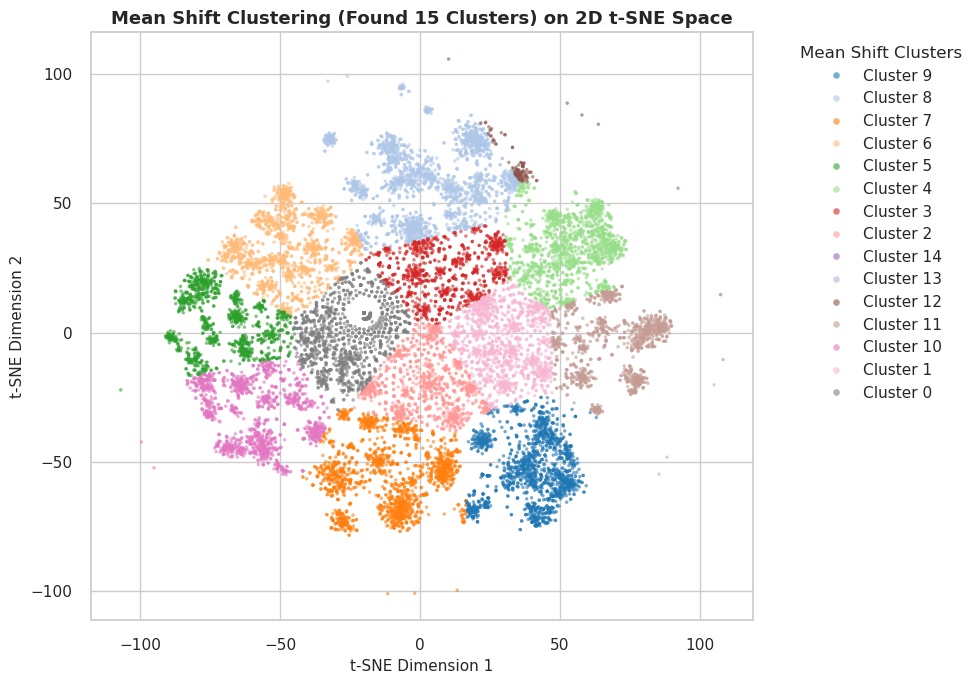

In [43]:
# 5. Plot the static layout using Seaborn
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Sort clusters by size so smaller ones don't get buried underneath
df_ms = df_ms.sort_values(by="Cluster", ascending=False)

sns.scatterplot(
    data=df_ms,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Cluster",
    palette="tab20",  # Distinct 20-color discrete mapping
    alpha=0.6,
    edgecolor=None,
    s=5,
)

# 6. Formatting titles and legends
plt.title(
    f"Mean Shift Clustering (Found {df_ms['Cluster'].nunique()} Clusters) on 2D t-SNE Space",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Mean Shift Clusters",
    markerscale=2,
)
plt.tight_layout()

plt.show()

#### **Findings**

Mean Shift identified several smooth and natural-looking clusters in the t-SNE space. Unlike KMeans, it did not force rigid cluster shapes, and unlike DBSCAN, it did not merge most points into one large cluster.

The results suggest that:

- The dataset contains multiple dense topic regions.
- Mean Shift captured the overall structure of the data reasonably well.
- Some overlap still exists because many document categories are semantically similar.

Overall, Mean Shift produced more balanced and natural cluster boundaries than KMeans and DBSCAN, but complete separation of topics remains difficult due to strong overlap in the text data.



## **Non-negative Matrix Factorization (NMF)**

NMF discovers hidden topics by decomposing the non-negative TF-IDF matrix into document-topic and topic-term matrices. It is particularly useful when stakeholders need human-readable themes rather than only cluster assignments.

NMF is included because stakeholders need more than cluster numbers. It converts the TF-IDF matrix into readable topic-word groups, which helps explain what the discovered document groups mean.

In [44]:
nmf = NMF(n_components=10, random_state=42)

W = nmf.fit_transform(X_tfidf)
H = nmf.components_

feature_names = vectorizer.get_feature_names_out()

In [45]:
for topic_idx, topic in enumerate(H):

    top_words = [feature_names[i] for i in topic.argsort()[-10:]]

    print(f"\nTopic {topic_idx+1}")
    print(top_words)


Topic 1
['want', 'really', 'time', 've', 'good', 'know', 'think', 'like', 'just', 'don']

Topic 2
['run', 'version', 'using', 'use', 'window', 'files', 'program', 'file', 'dos', 'windows']

Topic 3
['church', 'sin', 'christians', 'christian', 'faith', 'christ', 'believe', 'bible', 'jesus', 'god']

Topic 4
['floppy', 'bus', 'drives', 'card', 'hard', 'controller', 'disk', 'ide', 'scsi', 'drive']

Topic 5
['espn', 'play', 'players', 'season', 'baseball', 'hockey', 'year', 'team', 'games', 'game']

Topic 6
['help', 'information', 'looking', 'info', 'hi', 'advance', 'mail', 'know', 'does', 'thanks']

Topic 7
['edu', 'offer', 'shipping', '50', 'price', 'car', '10', 'sale', 'new', '00']

Topic 8
['shameful', 'intellect', 'skepticism', 'pitt', 'chastity', 'cadre', 'n3jxp', 'dsl', 'geb', 'edu']

Topic 9
['phone', 'algorithm', 'use', 'escrow', 'government', 'keys', 'clipper', 'encryption', 'chip', 'key']

Topic 10
['said', 'did', 'gun', 'state', 'armenians', 'jews', 'armenian', 'israel', 'gover

NMF returned **10 interpretable topic word lists**. Several topics are easy to label, including Windows/software, Christianity/religion, computer hardware, sports, encryption, and politics/international conflict. This output is highly valuable for explaining the analysis to stakeholders because it translates numerical patterns into readable themes.

The practical finding is that NMF can be used to draft labels for KMeans clusters or to summarize document themes for non-technical audiences.

## **Model Comparison**


To evaluate clustering quality, silhouette scores were calculated for each clustering algorithm using the 100-dimensional Truncated SVD feature space. The silhouette score measures how well documents fit within their assigned clusters while remaining separated from other clusters. Scores closer to 1 indicate stronger cluster separation, whereas negative scores suggest poor clustering structure or incorrect cluster assignments.

In [ ]:
# KMeans
kmeans_score = silhouette_score(X_svd, kmeans_labels)

# GMM
gmm_score = silhouette_score(X_svd, gmm_labels)

# DBSCAN
dbscan_score = silhouette_score(X_svd, dbscan_labels)

# Mean Shift
meanshift_score = silhouette_score(X_svd, meanshift_labels)

print(kmeans_score)
print(gmm_score)
print(dbscan_score)
print(meanshift_score)

0.0533853430713294
-0.1817595798379407
-0.18472248883754683
5.1797057498206675e-06


| Model      | Silhouette Score | Scalability | Interpretability | Overall Performance |
| ---------- | ---------------- | ----------- | ---------------- | ------------------- |
| KMeans     | **0.0534**       | Excellent   | High             | Best                |
| GMM        | -0.1818          | Moderate    | Moderate         | Weak                |
| DBSCAN     | -0.1847          | Moderate    | Poor             | Poor                |
| Mean Shift | 0.000005         | Poor        | Poor             | Weak                |

KMeans achieved the highest silhouette score among the evaluated models, indicating the best overall cluster separation and cohesion. However, all models produced relatively low silhouette scores. This is common in large text datasets because TF-IDF representations are extremely sparse and many discussion topics overlap semantically, making clean cluster boundaries difficult to achieve.

GMM produced negative silhouette scores, suggesting substantial overlap between clusters. Although soft probabilistic assignments can capture mixed-topic documents, the high-dimensional feature space reduced clustering stability.

DBSCAN performed poorly because density-based clustering struggles in sparse high-dimensional text spaces, where distances between documents become less meaningful. As a result, many documents were classified as noise or grouped into overly broad clusters.

Mean Shift generated silhouette scores close to zero, indicating weak cluster separation. The algorithm converged toward a few broad dense regions and failed to identify clear semantic groupings.

Despite the generally low silhouette scores, KMeans consistently outperformed the other approaches and provided the best balance between clustering quality, scalability, and interpretability.

## **Model Selection and Justification**

Based on the comparative analysis, the combination of Truncated SVD and KMeans clustering was selected as the final recommended pipeline.

Several factors contributed to this decision.

First, Truncated SVD efficiently compressed the sparse TF-IDF feature space while preserving the major semantic relationships between documents. Unlike PCA, it operated directly on sparse matrices and scaled efficiently to the full dataset.

Second, KMeans consistently produced the clearest cluster separation and the most interpretable document groupings among all evaluated clustering methods. The model also scaled efficiently and processed the full dataset in a relatively short time.

Although Gaussian Mixture Models provided more flexible soft clustering assignments, the increased computational complexity and sensitivity to initialization reduced their practical usability for large-scale deployment. DBSCAN and Mean Shift struggled significantly with the sparsity and high dimensionality of the text feature space and produced poor cluster separation.

Overall, the Truncated SVD + KMeans pipeline provided the best combination and was therefore selected as the final unsupervised learning framework for the project.

## **Key Findings**
After selecting the Truncated SVD + KMeans pipeline, Non-Negative Matrix Factorization (NMF) was used to extract interpretable topic keywords from the clustered documents.

Several meaningful themes emerged automatically from the unlabeled text corpus:

| Topic Theme               | Representative Keywords             |
| ------------------------- | ----------------------------------- |
| Space and Science         | nasa, orbit, launch, earth, shuttle |
| Cryptography and Security | encryption, key, chip, government   |
| Sports                    | hockey, team, season, game          |
| International Politics    | israel, peace, war, state           |


These results show that the unsupervised pipeline successfully identified meaningful semantic structure without using labeled training data.

Visualization using SVD and t-SNE projections further showed that KMeans produced clearer topic separation than DBSCAN and Mean Shift, which struggled with the sparse high-dimensional feature space.

The final pipeline demonstrates how unsupervised learning can support automated topic discovery, document organization, and large-scale text analysis.

## **Limitations and Future Work**

The TF-IDF representation used in this project ignores word order and semantic context, which limits the model’s ability to capture nuanced language meaning. In addition, KMeans assumes relatively balanced spherical clusters and forces each document into a single cluster, which may oversimplify overlapping topics.

Future work could improve clustering quality by replacing TF-IDF with transformer-based embeddings such as BERT or RoBERTa, which capture contextual semantic information. Non-linear dimensionality reduction methods such as UMAP and more flexible clustering algorithms such as HDBSCAN could also improve topic separation and better identify complex document structures.

## **Conclusion**

This project evaluated multiple unsupervised learning methods for large-scale text mining and topic discovery using the 20 Newsgroups dataset. Among the evaluated approaches, the combination of Truncated SVD and KMeans provided the best balance between clustering quality, scalability, and interpretability.

Although clustering performance was limited by the sparsity and semantic overlap of high-dimensional text data, the final pipeline successfully identified meaningful discussion themes without labeled training data. The results demonstrate the practical value of unsupervised learning for automated topic discovery and large-scale document organization.